In [1]:
# Importation des packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [100]:
# Importation des données
df = pd.read_excel('data/data.xlsx', header=1)

In [101]:
# Renommer les variables 
df = df.rename(columns={
    'Date operation': 'DATE_OPERATION', 
    'Montant': 'MONTANT', 
    'Duree': 'DUREE', 
    'PRIOD': 'PERIODE',
    'Taux %': 'TAUX_INT',
    'NBRE ECH': 'NB_ECH'})

In [102]:
pd.set_option('display.max_columns', None)

In [103]:
df = df[(df['VALEURGARANT'].notna()) & (df['PORTEF'] != 'FSE') & (df['SEX'].notna())]

In [104]:
df.shape

(927, 21)

In [105]:
df['INDLIB'].unique()

<StringArray>
['H�tel, Caf�, Retaurant, Spectacl',                    'Autre Service',
               'Industrie de P�che',                 'Commerce G�n�ral',
                                nan,      'B�timent et Travaux Publics',
      'Elevage, Production Animale',                           'Divers',
              'Production Agricole',                       'Transports',
            'Industrie Alimentaire', 'Indus. M�taux, Const M�ca & El�c',
  'Commerce V�hicules & Pi�ces D�t',  'Indus. Text Cuir et Habillement',
                   'Autre Commerce',  'Commerce Sp�cialis� Alimentaire',
 'Commerce Mat.1�re, Const, Quinca', 'Industrie Materiaux Construction',
  'Transit Manut, Auxiliare Transp',    'Industrie Bois et Ameublement',
  'Production et Distrib Eau/El�ct']
Length: 21, dtype: str

In [106]:
corrections = {
    'H�tel, Caf�, Retaurant, Spectacl': 'Hôtel, Café, Restaurant, Spectacle',
    'Industrie de P�che': 'Industrie de Pêche',
    'Commerce G�n�ral': 'Commerce Général',
    'B�timent et Travaux Publics': 'Bâtiment et Travaux Publics',
    'Elevage, Production Animale': 'Élevage, Production Animale',
    'Indus. M�taux, Const M�ca & El�c': 'Industrie Métaux, Construction Mécanique & Électrique',
    'Commerce V�hicules & Pi�ces D�t': 'Commerce Véhicules & Pièces Détachées',
    'Indus. Text Cuir et Habillement': 'Industrie Textile, Cuir et Habillement',
    'Commerce Sp�cialis� Alimentaire': 'Commerce Spécialisé Alimentaire',
    'Commerce Mat.1�re, Const, Quinca': 'Commerce Matières Premières, Construction, Quincaillerie',
    'Industrie Materiaux Construction': 'Industrie Matériaux Construction',
    'Transit Manut, Auxiliare Transp': 'Transit, Manutention, Auxiliaire Transport',
    'Production et Distrib Eau/El�ct': 'Production et Distribution Eau/Électricité'
}

df['INDLIB'] = df['INDLIB'].replace(corrections)

In [107]:
df.shape

(927, 21)

# Netoyage des données

### DATE_OPERATION

In [108]:
df['DATE_OPERATION'] = pd.to_datetime(
    df['DATE_OPERATION'],
    format='%d-%b-%y',
    errors='coerce'
)

### INDLIB & IND

In [109]:
# Pourcentage des valeurs manquantes
print(f"Valeurs manquantes: {df['INDLIB'].isnull().sum()}/{df.shape[0]} ({round((df['INDLIB'].isnull().sum() / df.shape[0]) * 100, 2)}%)")

Valeurs manquantes: 21/927 (2.27%)


In [110]:
# Supprimer les lignes où INDLIB est manquante
df = df.dropna(subset=['INDLIB'])

In [111]:
# Regroupement de la variable INDLIB en grandes catégories économiques

mapping_indlib = {
    # Commerce
    'Commerce Général': 'Commerce',
    'Autre Commerce': 'Commerce',
    'Commerce Véhicules & Pièces Détachées': 'Commerce',
    'Commerce Spécialisé Alimentaire': 'Commerce',
    'Commerce Matières Premières, Construction, Quincaillerie': 'Commerce',

    # Services
    'Autre Service': 'Services',
    'Hôtel, Café, Restaurant, Spectacle': 'Services',
    'Transit, Manutention, Auxiliaire Transport': 'Services',

    # Industrie
    'Industrie de Pêche': 'Industrie',
    'Industrie Alimentaire': 'Industrie',
    'Industrie Bois et Ameublement': 'Industrie',
    'Industrie Matériaux Construction': 'Industrie',
    'Industrie Métaux, Construction Mécanique & Électrique': 'Industrie',
    'Industrie Textile, Cuir et Habillement': 'Industrie',

    # Agriculture / Élevage
    'Production Agricole': 'Agriculture/Élevage',
    'Élevage, Production Animale': 'Agriculture/Élevage',

    # BTP / Construction
    'Bâtiment et Travaux Publics': 'BTP/Construction',

    # Transport
    'Transports': 'Transport',

    # Eau / Électricité
    'Production et Distribution Eau/Électricité': 'Eau/Électricité',

    # Autres
    'Divers': 'Autres'
}

# Trouver la position de INDLIB
position_indlib = df.columns.get_loc('INDLIB')

# Créer INDLIB_GROUPE directement après INDLIB
df.insert(
    loc=position_indlib + 1,
    column='INDLIB_GROUPE',
    value=df['INDLIB'].map(mapping_indlib)
)

# Vérifier les modalités non catégorisées
df[df['INDLIB_GROUPE'].isna()]['INDLIB'].unique()

<StringArray>
[]
Length: 0, dtype: str

In [112]:
df['INDLIB_GROUPE'].value_counts(normalize=True)

INDLIB_GROUPE
Commerce               0.750552
Services               0.111479
Industrie              0.047461
BTP/Construction       0.028698
Agriculture/Élevage    0.027594
Autres                 0.024283
Transport              0.008830
Eau/Électricité        0.001104
Name: proportion, dtype: float64

### MONTANT

<Axes: >

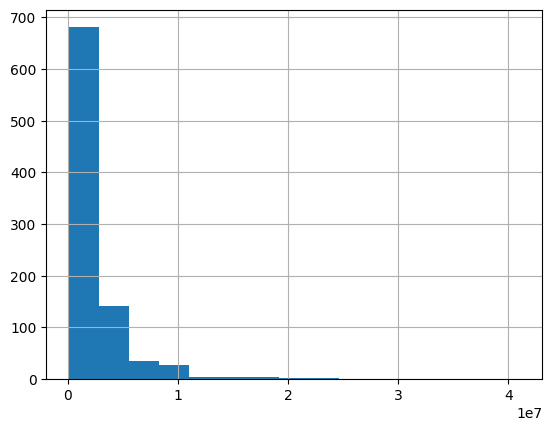

In [113]:
df['MONTANT'].hist(bins=15)

In [114]:
(df['MONTANT'] <= 0).sum()

np.int64(0)

### DATENAIS

In [115]:
def clean_birth_date(x):
    if pd.isna(x):
        return pd.NaT

    # If already datetime
    if isinstance(x, (pd.Timestamp, datetime)):
        date = pd.to_datetime(x)

    # If Excel serial number
    elif isinstance(x, (int, float)):
        date = pd.to_datetime(x, origin='1899-12-30', unit='D')

    # If text like 25-MAY-72
    else:
        date = pd.to_datetime(x, format='%d-%b-%y', errors='coerce')

    # Correct future birth dates caused by 2-digit year problem
    if pd.notna(date) and date.year > datetime.today().year:
        date = date - pd.DateOffset(years=100)

    return date

df['DATENAIS'] = df['DATENAIS'].apply(clean_birth_date)

In [116]:
# Convert DATENAIS to datetime
df['DATENAIS'] = pd.to_datetime(df['DATENAIS'], errors='coerce')

# Calculate age
today = pd.Timestamp.today()

age = (
    today.year 
    - df['DATENAIS'].dt.year 
    - (
        (today.month < df['DATENAIS'].dt.month) |
        ((today.month == df['DATENAIS'].dt.month) & (today.day < df['DATENAIS'].dt.day))
    )
)

# Remove AGE if it already exists
df = df.drop(columns=['AGE'], errors='ignore')

# Insert AGE directly after DATENAIS
pos = df.columns.get_loc('DATENAIS') + 1
df.insert(pos, 'AGE', age)

### DEPNAISLIB

In [117]:
# Trouver la position de DEPNAISLIB
position_depnaislib = df.columns.get_loc('DEPNAISLIB')

# Créer WILAYA_NAISSANCE directement après DEPNAISLIB
df.insert(
    loc=position_depnaislib + 1,
    column='WILAYA_NAISSANCE',
    value=(
        df['DEPNAISLIB']
        .str.split(' - ')
        .str[0]
        .replace('Toute la Mauritanie', 'Inconnu')
        .fillna('Inconnu')
    )
)

# Vérifier la distribution en pourcentage
df['WILAYA_NAISSANCE'].value_counts(normalize=True).mul(100).round(2)

WILAYA_NAISSANCE
Inconnu             39.96
Nouakchott          21.74
Trarza               9.16
Assaba               5.41
Brakna               3.42
Hodh el Gharbi       3.31
Guidimakha           2.65
Adrar                2.54
Tagant               2.54
Gorgol               2.43
Hodh Ech Chargui     2.21
Nouadhibou           1.99
Inchiri              1.99
Tiris Zemmour        0.66
Name: proportion, dtype: float64

In [118]:
df.head(3)

,DATE_OPERATION,LIBELLE,ACT,IND,INDLIB,INDLIB_GROUPE,PORTEF,MONTANT,DUREE,PERIODE,TAUX_INT,NB_ECH,SEX,VALEURGARANT,AGENCELIB,IMPAYE,NBIMP,MNTREMB,DATENAIS,AGE,ETATCIVIL,DEPNAISLIB,WILAYA_NAISSANCE,SECT_ACTIV
18,2017-04-20,CRDT LT- MOURABAHA FADES DD,DD,23.0,"Hôtel, Café, Restaurant, Spectacle",Services,DD,16000000.0,96,T,8.0,32,Female,26000000.0,NOUAKCHOTT 1 - SIEGE,0.0,0,788565.21,1966-07-14,59,Married,Toute la Mauritanie,Inconnu,AUTRES SOCIETES
173,2013-02-19,CRDT MT- MOURABAHA FADES DC,DC,24.0,Autre Service,Services,DDC,1000000.0,48,M,8.0,48,Male,1089103.0,NOUAKCHOTT 1 - SIEGE,0.0,0,25608.95,1972-05-25,53,Married,Toute la Mauritanie,Inconnu,ENTREPRISES INDIVIDUELLES
174,2013-02-21,CRDT MT- MOURABAHA FADES DC,DC,24.0,Autre Service,Services,DDC,300000.0,36,M,6.0,36,Female,1180000.0,NOUAKCHOTT 1 - SIEGE,0.0,0,9293.61,1966-12-30,59,Divorced,Toute la Mauritanie,Inconnu,ENTREPRISES INDIVIDUELLES


In [119]:
# Supprimer des variables insignificatifs
df.drop(columns=['LIBELLE', 'IND', 'INDLIB', 'DATENAIS', 'DEPNAISLIB', 'AGENCELIB'], inplace=True)

In [120]:
df.head(3)

,DATE_OPERATION,ACT,INDLIB_GROUPE,PORTEF,MONTANT,DUREE,PERIODE,TAUX_INT,NB_ECH,SEX,VALEURGARANT,IMPAYE,NBIMP,MNTREMB,AGE,ETATCIVIL,WILAYA_NAISSANCE,SECT_ACTIV
18,2017-04-20,DD,Services,DD,16000000.0,96,T,8.0,32,Female,26000000.0,0.0,0,788565.21,59,Married,Inconnu,AUTRES SOCIETES
173,2013-02-19,DC,Services,DDC,1000000.0,48,M,8.0,48,Male,1089103.0,0.0,0,25608.95,53,Married,Inconnu,ENTREPRISES INDIVIDUELLES
174,2013-02-21,DC,Services,DDC,300000.0,36,M,6.0,36,Female,1180000.0,0.0,0,9293.61,59,Divorced,Inconnu,ENTREPRISES INDIVIDUELLES


In [123]:
df.shape

(906, 18)

In [122]:
# Exporter les données 
df.to_excel('data/working_dataset.xlsx', index=False)

# Ingénerie des données